In [123]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
# import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import scipy.optimize
# print(scipy.__version__)

# from scipy.interpolate import make_smoothing_spline
import os
lam = 20
import random

#import tqdm # from ben, just a progress bar

In [124]:
import sys
sys.executable

'/usr/bin/python3'

In [125]:
port = "/dev/ttyACM1"  # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True

In [126]:
def beta_to_c(beta, N_o, V=0.58, R=1_000, R_max=10_000, c_max=128):
    """Converts a desired inverse temperature, beta, to a digipot setting, c, per hardware."""
    b = np.asarray(beta, dtype=float)
    return c_max * ((R / R_max) * (1.0 - V * np.sqrt(N_o * b / 3.0)) + 1.0)

In [127]:
aConvert = (3.3)/(4095.)

In [128]:
RW = ReadWrite(ser)

In [129]:
RW.send_recieve("fb;0;")

FB, 0


In [142]:
isH = 1
digivals = [0, 20, 50, 70, 90, 100, 110, 120, 128]
# digivals = [0]
results = []
for digival in digivals:
    #print("1")
    if isH:
        tempside = 'h'
    else:
        tempside = 'v'
        
    #print("2")
    RW.send_recieve("set{}temp;{};".format(tempside, digival))
    time.sleep(1)
    #print("3")
    RW.clear_output()
    time.sleep(1)
    RW.send_message("ames;0;")
    time.sleep(1)
    out = RW.measure()
    
    a0 = float(out['analogZero'])/int(out['nmestimes'])*aConvert
    
    time.sleep(1)
    RW.send_message("sampletemp;500;10;{};".format(isH))
    out = RW.measure()
    
    tempSig = [x*aConvert for x in out['analogTemp']]
    
    beta = 1./np.var(tempSig)

    c = beta_to_c(beta, 1)

    localresult = {'digi': digival, 'a0': a0, 'tempSig': tempSig, 'tempSide': tempside, 'beta': beta, 'c_pred': c}
    results.append(localresult)
    time.sleep(1)

set Htemp, 0
nmestimes, 5
analogZero, 12225
analogH, [12192]
sampling temperature signal
H temp
analogTemp, [2492, 2500, 2511, 2513, 2501, 2492, 2486, 2473, 2464, 2461, 2445, 2438, 2428, 2426, 2412, 2410, 2393, 2383, 2390, 2400, 2406, 2414, 2424, 2432, 2441, 2452, 2460, 2471, 2480, 2489, 2496, 2504, 2511, 2499, 2491, 2485, 2470, 2467, 2458, 2447, 2438, 2432, 2421, 2412, 2401, 2392, 2388, 2386, 2394, 2407, 2415, 2424, 2434, 2442, 2454, 2460, 2469, 2477, 2487, 2497, 2507, 2511, 2504, 2493, 2485, 2478, 2466, 2455, 2451, 2437, 2431, 2426, 2414, 2402, 2396, 2387, 2387, 2395, 2405, 2417, 2423, 2429, 2440, 2448, 2459, 2468, 2479, 2486, 2501, 2504, 2513, 2504, 2495, 2486, 2476, 2468, 2458, 2447, 2442, 2430, 2422, 2413, 2405, 2396, 2388, 2382, 2391, 2398, 2408, 2419, 2428, 2443, 2445, 2453, 2465, 2475, 2485, 2493, 2502, 2509, 2507, 2498, 2488, 2478, 2470, 2462, 2453, 2443, 2433, 2421, 2417, 2408, 2395, 2391, 2379, 2390, 2399, 2410, 2419, 2425, 2436, 2444, 2452, 2464, 2472, 2478, 2489, 2499, 250

set Htemp, 70
nmestimes, 5
analogZero, 12222
analogH, [12199]
sampling temperature signal
H temp
analogTemp, [2486, 2506, 2522, 2539, 2559, 2573, 2561, 2546, 2525, 2510, 2491, 2474, 2457, 2441, 2420, 2406, 2388, 2369, 2352, 2328, 2319, 2337, 2357, 2375, 2391, 2410, 2428, 2450, 2462, 2479, 2502, 2517, 2536, 2554, 2567, 2565, 2546, 2531, 2510, 2496, 2475, 2460, 2442, 2425, 2406, 2390, 2372, 2355, 2340, 2317, 2332, 2354, 2371, 2390, 2407, 2426, 2441, 2462, 2483, 2497, 2517, 2533, 2551, 2571, 2565, 2545, 2533, 2512, 2494, 2476, 2459, 2441, 2424, 2403, 2392, 2376, 2355, 2340, 2319, 2331, 2350, 2368, 2389, 2405, 2425, 2440, 2461, 2480, 2498, 2512, 2534, 2548, 2564, 2573, 2550, 2534, 2518, 2502, 2482, 2462, 2448, 2428, 2411, 2394, 2377, 2360, 2341, 2326, 2332, 2350, 2370, 2389, 2404, 2424, 2439, 2459, 2478, 2493, 2510, 2530, 2546, 2566, 2572, 2554, 2537, 2519, 2500, 2484, 2466, 2446, 2431, 2413, 2398, 2377, 2362, 2343, 2327, 2332, 2351, 2366, 2384, 2402, 2420, 2438, 2457, 2475, 2489, 2514, 25

set Htemp, 110
nmestimes, 5
analogZero, 12234
analogH, [12193]
sampling temperature signal
H temp
analogTemp, [2286, 2334, 2372, 2413, 2451, 2494, 2534, 2570, 2609, 2653, 2695, 2737, 2706, 2665, 2626, 2584, 2546, 2503, 2465, 2424, 2386, 2344, 2305, 2265, 2227, 2186, 2162, 2206, 2245, 2288, 2325, 2369, 2410, 2451, 2487, 2530, 2569, 2609, 2653, 2691, 2731, 2706, 2668, 2630, 2590, 2548, 2510, 2472, 2426, 2390, 2349, 2311, 2268, 2231, 2193, 2152, 2197, 2242, 2282, 2318, 2363, 2404, 2440, 2486, 2522, 2569, 2607, 2645, 2684, 2726, 2721, 2675, 2640, 2597, 2559, 2517, 2478, 2438, 2397, 2356, 2314, 2278, 2237, 2197, 2155, 2194, 2232, 2277, 2320, 2361, 2402, 2441, 2484, 2525, 2562, 2605, 2642, 2681, 2725, 2720, 2681, 2639, 2599, 2561, 2519, 2482, 2439, 2400, 2360, 2323, 2280, 2244, 2200, 2162, 2190, 2231, 2271, 2314, 2354, 2396, 2433, 2475, 2517, 2554, 2590, 2636, 2675, 2712, 2728, 2686, 2639, 2604, 2565, 2525, 2486, 2448, 2409, 2367, 2326, 2290, 2251, 2209, 2172, 2177, 2224, 2266, 2303, 2343, 2

Text(0, 0.5, 'Number of occurrences')

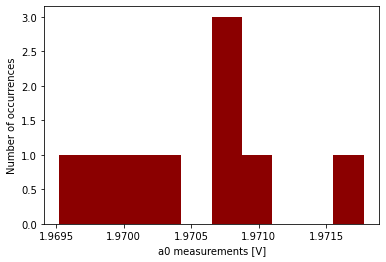

In [143]:
plt.hist([x['a0'] for x in results], color='darkred')
plt.xlabel('a0 measurements [V]')
plt.ylabel('Number of occurrences')

Text(0, 0.5, 'T wave measurements [V]')

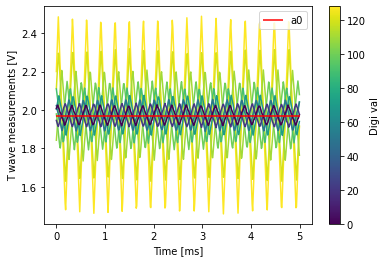

In [144]:
plt.hlines(np.mean([x['a0'] for x in results]), 0, len(results[0]['tempSig'])*10./1e3, color='red', label='a0')

whichcmap = 'viridis'
cmap = plt.cm.get_cmap(whichcmap)

for n in results:
    plt.plot(np.arange(len(n['tempSig']))*10./1e3, n['tempSig'], c=cmap(n['digi']/128.), zorder=-1*n['digi'])

norm = mcolors.Normalize(vmin=0, vmax=128)
mappable = cm.ScalarMappable(norm=norm, cmap=whichcmap)

plt.colorbar(mappable, label='Digi val')
plt.legend()
plt.xlabel('Time [ms]')
plt.ylabel('T wave measurements [V]')

Text(0, 0.5, 'Number of occurrences')

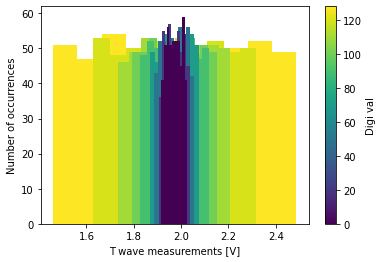

In [145]:
for n in results:
    plt.hist(n['tempSig'], label=n['digi'], zorder=-1*n['digi'], color=cmap(n['digi']/128.))

plt.colorbar(mappable, label='Digi val')

plt.xlabel('T wave measurements [V]')
plt.ylabel('Number of occurrences')

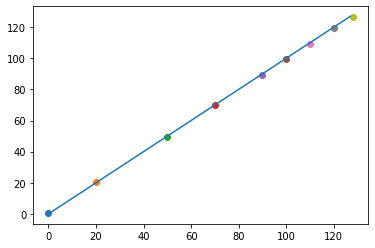

In [147]:
for n in results:
    plt.scatter(n['digi'], n['c_pred'])
plt.plot(np.arange(0, 128),np.arange(0, 128))

Text(0, 0.5, 'T Wave Amplitude [V]')

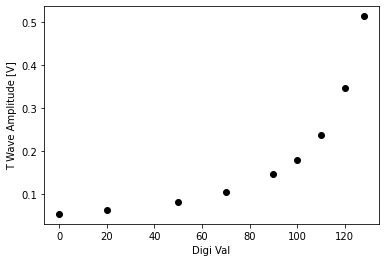

In [119]:
for n in results:
    stdev = np.std(n['tempSig'])
    vrange = np.max(n['tempSig']) - np.min(n['tempSig'])
    amp = vrange/2.
    plt.plot(n['digi'], amp, 'o-', c='k')
plt.xlabel('Digi Val')
plt.ylabel('T Wave Amplitude [V]')

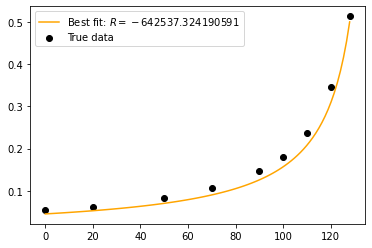

In [120]:
amps = []
cs = []

for n in results:
    vrange = np.max(n['tempSig']) - np.min(n['tempSig'])
    amp = vrange/2.
    c = n['digi']
         
    amps.append(amp)
    cs.append(c)
    
amps = np.array(amps)
cs = np.array(cs)

def v_divide(v_in, r1, r2):
    return v_in * r_2 / (r_1 + r_2)

def digi_amp(c, r_max, r_2, v_amp):
    r_d = ((128 - c)/128) * r_max
    r_frac = r_2 / (r_2 + r_d)
    return r_frac * v_amp

popt, _ = scipy.optimize.curve_fit(digi_amp, cs, amps, (10_000, 1_000, 0.5))
full_cs = np.linspace(0, 128, 100)
#fit_amps = digi_amp(full_cs, popt[0], popt[1], popt[2])
fit_amps = digi_amp(full_cs, 10_000, 1_000, 0.5)

plt.scatter(cs, amps, c='k')
plt.plot(full_cs, fit_amps, c='orange')
plt.legend([rf'Best fit: $R={popt[1]}$', 'True data'])

In [121]:
for n in results:
    print(np.mean(n['tempSig']), n['a0'])

1.9693255677655679 1.969201465201465
1.9701249816849817 1.9693626373626376
1.9698139194139195 1.9688791208791208
1.9691289377289376 1.969040293040293
1.970012161172161 1.9700073260073259
1.9699347985347986 1.9693626373626376
1.9700460073260073 1.9693626373626376
1.9699509157509159 1.969040293040293
1.9695383150183148 1.9685567765567766


In [122]:
results

[{'digi': 0,
  'a0': 1.969201465201465,
  'tempSig': [1.9389010989010989,
   1.93003663003663,
   1.9243956043956043,
   1.917948717948718,
   1.9235897435897436,
   1.9316483516483516,
   1.938095238095238,
   1.9437362637362636,
   1.9534065934065934,
   1.95985347985348,
   1.9671062271062272,
   1.971941391941392,
   1.9848351648351648,
   1.9896703296703298,
   1.9977289377289378,
   2.0025641025641026,
   2.013040293040293,
   2.021098901098901,
   2.0194871794871796,
   2.0098168498168496,
   2.004981684981685,
   1.996923076923077,
   1.988058608058608,
   1.9816117216117215,
   1.9735531135531135,
   1.9646886446886447,
   1.95985347985348,
   1.9526007326007326,
   1.9445421245421246,
   1.9356776556776556,
   1.9276190476190476,
   1.9195604395604395,
   1.917142857142857,
   1.921978021978022,
   1.9308424908424908,
   1.9389010989010989,
   1.9461538461538461,
   1.9534065934065934,
   1.9582417582417582,
   1.967912087912088,
   1.9743589743589745,
   1.984029304029304,
 

In [107]:
from datetime import datetime
from pathlib import Path
import json

out_path = Path(f"twave_mes_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")

with out_path.open("w", encoding="utf-8") as f:
    json.dump(results, f)
    
print("Saved:", out_path.resolve())

Saved: /home/latte/python/RKM/twave_mes_20260511_145030.json


In [148]:
ser.close()